In [2]:
# 06_loyalty_kmeans.ipynb

# 1. DATA LOADING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the preprocessed dataset
df = pd.read_csv("preprocessed_customer_data.csv")

In [3]:
# 2. FEATURE SELECTION (LOYALTY & ENGAGEMENT)

# Focus on how long they’ve been a customer and their purchase activity
loyalty_features = [
    'Customer_Tenure', 'Recency', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]
X = df[loyalty_features]

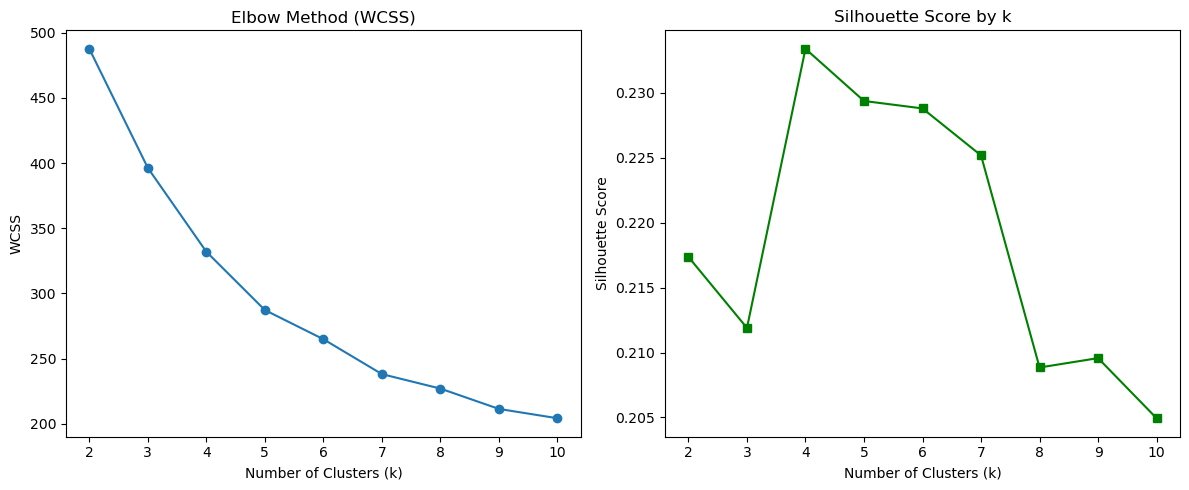

In [4]:
# 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (k)

wcss = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Elbow and Silhouette Score
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(k_values, wcss, marker='o')
ax[0].set_title("Elbow Method (WCSS)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("WCSS")

ax[1].plot(k_values, silhouette_scores, marker='s', color='green')
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [8]:
# 4. APPLY K-MEANS CLUSTERING

optimal_k = 4  # Choose based on analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['LoyaltyCluster_KMeans'] = kmeans.fit_predict(X)

score = silhouette_score(X, df['LoyaltyCluster_KMeans'])
print(f"Silhouette Score (k={optimal_k}): {score:.4f}")

Silhouette Score (k=4): 0.2334



📊 Loyalty & Engagement Cluster Profiles:


,Customer_Tenure,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
LoyaltyCluster_KMeans,,,,,,,
0,0.222245,0.254866,0.127392,0.129993,0.082124,0.398190,0.236631
1,0.619879,0.623700,0.153599,0.215545,0.175052,0.790840,0.200943
2,0.437469,0.781198,0.140787,0.115077,0.059224,0.294852,0.290079
3,0.778257,0.295664,0.200982,0.159266,0.081426,0.370166,0.325138


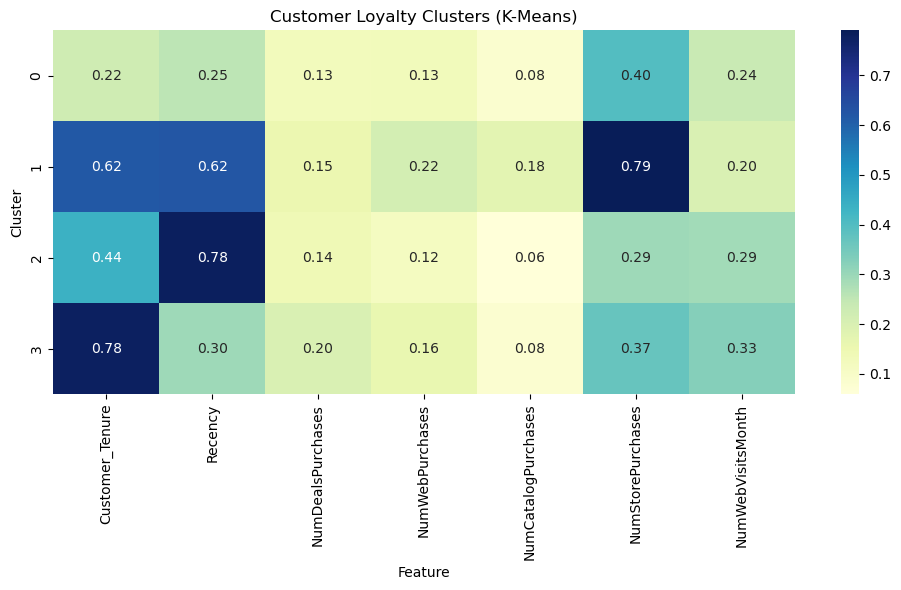

In [10]:
# 5. CLUSTER PROFILE ANALYSIS

cluster_profile = df.groupby('LoyaltyCluster_KMeans')[loyalty_features].mean()
print("\n📊 Loyalty & Engagement Cluster Profiles:")
display(cluster_profile)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Customer Loyalty Clusters (K-Means)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

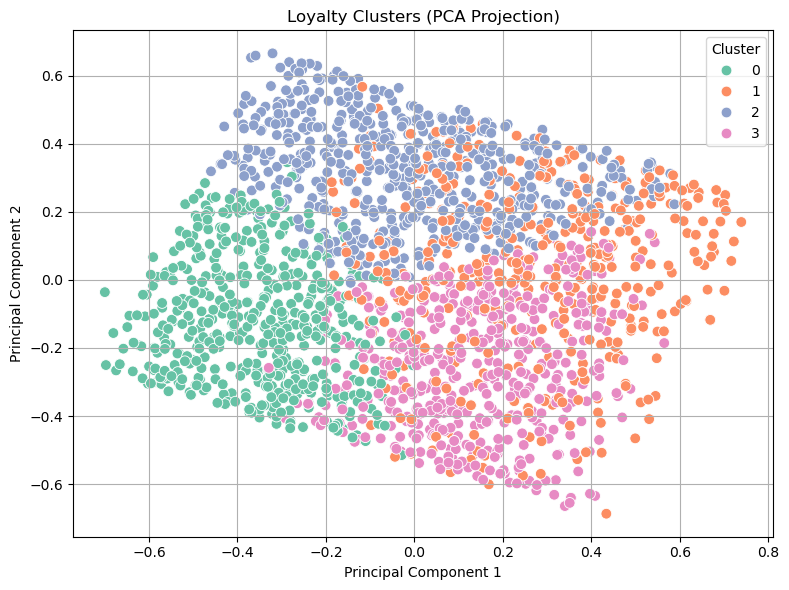

In [12]:
# 6. VISUALIZE CLUSTERS USING PCA (2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['LoyaltyCluster_KMeans']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title("Loyalty Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()